# Chapter three: Latent Space Analysis

## Generator Constraint: Prototype Regularization

Based on the latent space analysis above, we define the per-class centroids $\bar{z}_y$
that can serve as the anchor for prototype regularization.

The modified generator loss with constraint is:

$$J(w) := \underbrace{\mathbb{E}_{y,z}\left[\ell\left(\sigma\left(\frac{1}{K}\sum_k g(z;\theta^p_k)\right), y\right)\right]}_{\text{ensemble classification loss}} + \underbrace{\lambda \cdot \mathbb{E}_{y, z\sim G_w(\cdot|y)} \left[ \|z - \bar{z}_y\|^2 \right]}_{\text{prototype regularization}}$$

This ensures generated representations stay near the latent region occupied by real
patients of each class. The hyperparameter $\lambda$ controls the trade-off between
ensemble consensus (original objective) and distributional fidelity (constraint).

The main idea is that since the statistics can not be trully trusted in order to make real clinical vectors, they must be generated close to real ones, like reducing the noise from it.

In [1]:
# Cell 1 — imports
import os, sys, json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, '..')
from UC1Utils import prepare_data, ensure_data, CSV_MAIN
from UC1FLUtils import MLP
from UC1PrintingUtils import plot_latent_pca, plot_latent_prototypes

SEED    = 42
PALETTE = {'Not readmitted': '#4C72B0', 'Readmitted (<30d)': '#DD8452'}
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('figures', exist_ok=True)

/mnt/c/Users/Marc/Documents/Uni/4t/TFG/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cell 2 — load checkpoint and extract latent representations
ensure_data()
X, y, _, _ = prepare_data(CSV_MAIN, verbose=False)

CKPT_PATH = '../01_Centralized/models/mlp_centralized.pt'
if not os.path.exists(CKPT_PATH):
    print(f'Checkpoint not found at {CKPT_PATH}.')
    print('Run 01_UC1_Centralized.ipynb first.')
    LATENT_LOADED = False
else:
    ckpt       = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    hidden_dim = ckpt.get('hidden_dim', 256)
    dropout    = ckpt.get('dropout',    0.3)
    scaler     = ckpt.get('scaler',     StandardScaler())

    model = MLP(input_dim=X.shape[1], hidden_dim=hidden_dim, dropout=dropout).to(device)

    # Remap state_dict keys from old net.* format if needed
    orig_sd = ckpt['model_state_dict']
    new_sd  = {}
    for k, v in orig_sd.items():
        if k.startswith('net.'):
            idx  = int(k.split('.')[1])
            rest = '.'.join(k.split('.')[2:])
            if idx < 12:
                new_sd[f'feature_extractor.{idx}.{rest}'] = v
            else:
                new_sd[f'predictor.{rest}'] = v
        else:
            new_sd[k] = v
    model.load_state_dict(new_sd, strict=False)
    model.eval()

    X_scaled = scaler.transform(X) if hasattr(scaler, 'mean_') else X
    X_t = torch.tensor(X_scaled, dtype=torch.float32)
    latent_vecs = []
    with torch.no_grad():
        for (xb,) in DataLoader(TensorDataset(X_t), batch_size=2048):
            latent_vecs.append(model.encode(xb.to(device)).cpu().numpy())
    Z = np.concatenate(latent_vecs, axis=0)
    print(f'Latent space shape: {Z.shape}')
    LATENT_LOADED = True

✓ CSV files already present, skipping extraction.
Latent space shape: (97825, 128)


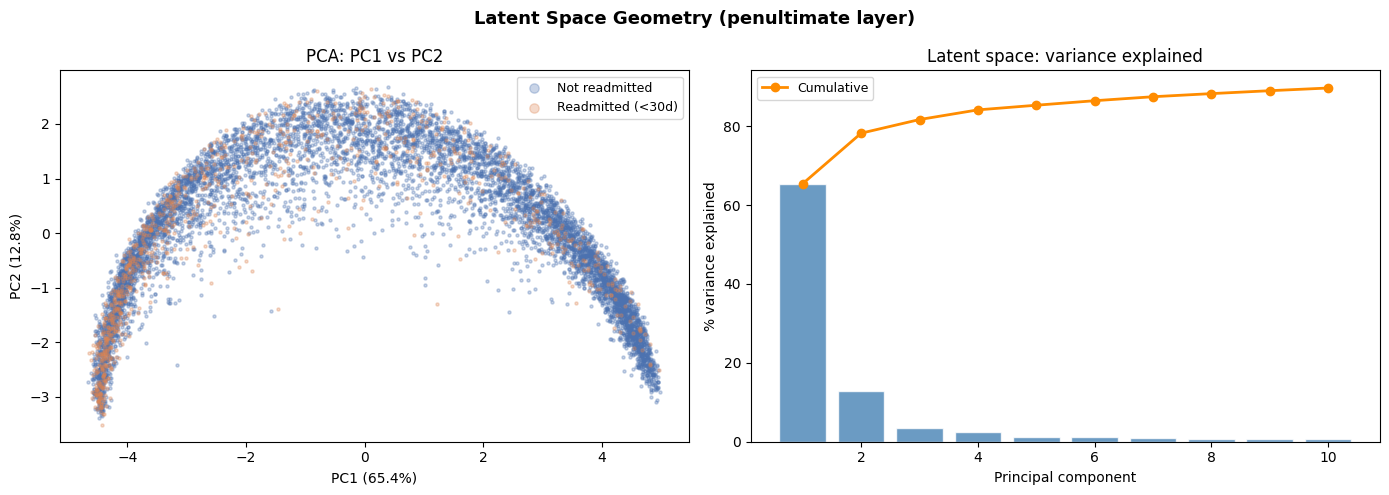


Latent space class-conditional statistics:
  Class 0 — mean norm: 5.784 | mean intra-class dist (sample): 3.407
  Class 1 — mean norm: 5.892 | mean intra-class dist (sample): 3.617
  Inter-class centroid distance: 2.031
  Latent dimension: 128


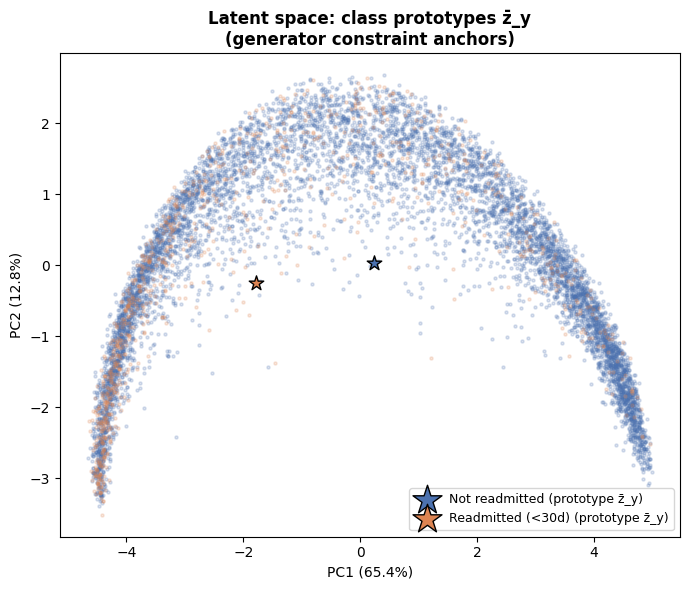

Prototype centroids (z̄_y) computed:
  z̄_{y=0}: shape=(128,), norm=5.784, mean std=0.288
  z̄_{y=1}: shape=(128,), norm=5.892, mean std=0.271

Mean intra-class variance: class0=0.123, class1=0.109
Suggested λ starting point: ~0.1 (ablate over [0.0, 0.01, 0.1, 1.0])

Prototypes saved.


In [3]:
# Cell 3 — PCA, prototypes, save
if LATENT_LOADED:
    pca = PCA(n_components=10)
    pca.fit(Z)

    Z_pca, idx_sub = plot_latent_pca(Z, y, pca, PALETTE, SEED)

    prototypes = {0: Z[y == 0].mean(axis=0), 1: Z[y == 1].mean(axis=0)}
    plot_latent_prototypes(Z, y, pca, prototypes, PALETTE, Z_pca, idx_sub)

    np.save('prototypes_class0.npy', prototypes[0])
    np.save('prototypes_class1.npy', prototypes[1])
    print('\nPrototypes saved.')